<a href="https://colab.research.google.com/github/noviansyah972/DataScience2026_240401010138_NoviansyahRamadhan/blob/main/Pertemuan5_NoviansyahRamadhan_240401010132.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Identitas Mahasiswa

**Nama Lengkap:** Noviansyah Ramadhan

**NIM:** 240401010132

**Kelas:** IF-403

In [1]:
#1 Load & inspect dataset
import pandas as pd
import numpy as py
import matplotlib.pyplot as plt
import seaborn as sns

df = sns.load_dataset('tips')
print(df.shape, df.dtypes)
print(df.describe().round(2))

(244, 7) total_bill     float64
tip            float64
sex           category
smoker        category
day           category
time          category
size             int64
dtype: object
       total_bill     tip    size
count      244.00  244.00  244.00
mean        19.79    3.00    2.57
std          8.90    1.38    0.95
min          3.07    1.00    1.00
25%         13.35    2.00    2.00
50%         17.80    2.90    2.00
75%         24.13    3.56    3.00
max         50.81   10.00    6.00


/tmp/ipykernel_592/294977996.py:15: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  avg_by_day = df.groupby('day')['total_bill'].mean()


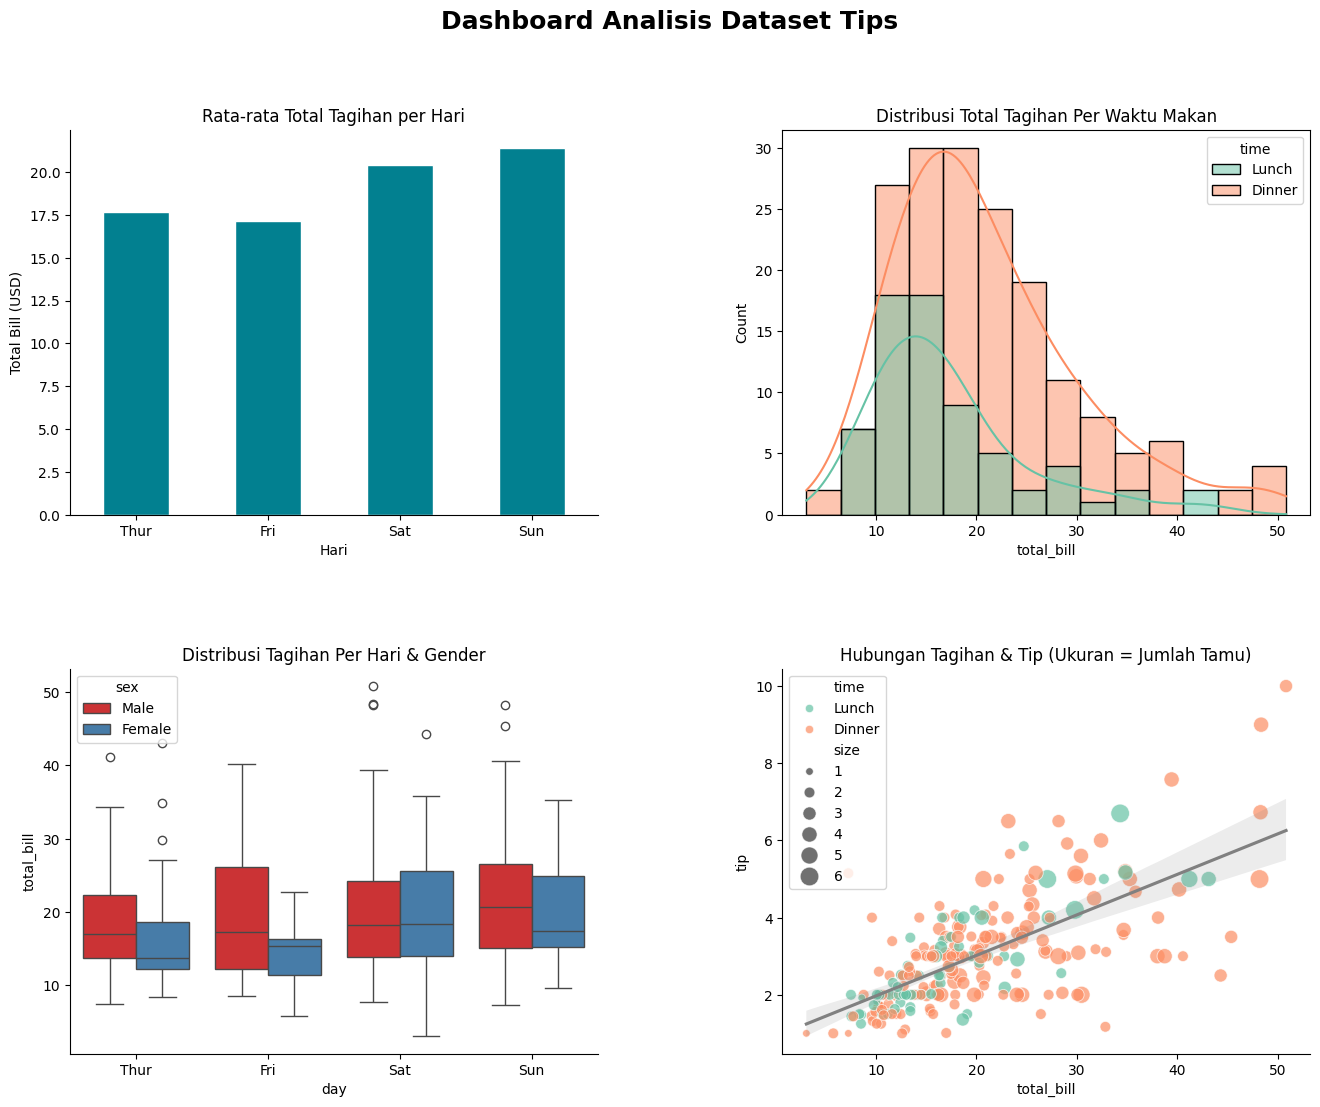

Dashboard tersimpan sebagai dashboard tips.png


In [4]:
#2 Setup figure layout
fig = plt.figure(figsize=(16, 12))
fig.suptitle('Dashboard Analisis Dataset Tips',
             fontsize=18, fontweight='bold')
# Grid 2 x 2 subplot
gs = fig.add_gridspec(2, 2, figure=fig,
                      hspace=0.4, wspace=0.35)

ax1 = fig.add_subplot(gs[0, 0])
ax2 = fig.add_subplot(gs[0, 1])
ax3 = fig.add_subplot(gs[1, 0])
ax4 = fig.add_subplot(gs[1, 1])

#3 Grafik 1: Bar chart
avg_by_day = df.groupby('day')['total_bill'].mean()
avg_by_day.plot(
    kind='bar',
    ax=ax1,
    color='#028090',
    edgecolor='white',
    width=0.5)
ax1.set_title('Rata-rata Total Tagihan per Hari')
ax1.set_xlabel('Hari'); ax1.set_ylabel('Total Bill (USD)')
ax1.tick_params(axis='x', rotation=0)
ax1.spines[['top', 'right']].set_visible(False)

#4 Grafik 2: Histogram + KDE
sns.histplot(data=df, x='total_bill', hue='time',
             kde=True, palette='Set2', ax=ax2)
ax2.set_title('Distribusi Total Tagihan Per Waktu Makan')
ax2.spines[['top','right']].set_visible=(False)

#5 Grafik 3: Boxplot
sns.boxplot(data=df, x='day', y='total_bill',
            hue='sex', palette='Set1', ax=ax3)
ax3.set_title('Distribusi Tagihan Per Hari & Gender')
ax3.spines[['top', 'right']].set_visible(False)

#6 Grafik 4: Scatterplot
sns.scatterplot(data=df, x='total_bill', y='tip',
                hue='time', size='size', sizes=(30, 180),
                palette='Set2', alpha=0.7, ax=ax4)
sns.regplot(data=df, x='total_bill', y='tip',
            scatter=False, color='gray', ax=ax4)
ax4.set_title('Hubungan Tagihan & Tip (Ukuran = Jumlah Tamu)')
ax4.spines[['top', 'right']].set_visible(False)

#7 Ekspor
plt.savefig('dashboard_tips.png', dpi=150, bbox_inches='tight')
plt.show()
print('Dashboard tersimpan sebagai dashboard tips.png')

### Analisis Grafik 1: Rata-rata Total Tagihan per Hari

**What?** Grafik batang menunjukkan bahwa rata-rata total tagihan (`total_bill`) tertinggi terjadi pada **Minggu** sekitar **22 USD**, diikuti **Sabtu** sekitar **20 USD**. Hari **Kamis** dan **Jumat** memiliki rata-rata tagihan yang lebih rendah, masing-masing sekitar **18 USD** dan **17 USD**.

**So what?** Hal ini menunjukkan bahwa pelanggan cenderung mengeluarkan uang lebih banyak saat akhir pekan dibandingkan hari kerja. Informasi ini penting bagi pemilik restoran untuk memperkirakan potensi pendapatan harian.

**Now what?** Analisis selanjutnya dapat membandingkan apakah peningkatan tagihan pada akhir pekan juga diikuti oleh peningkatan jumlah pelanggan atau besarnya tip yang diberikan.

### Analisis Grafik 2: Distribusi Total Tagihan Berdasarkan Waktu

**What?** Histogram menunjukkan bahwa transaksi **Dinner** jauh lebih banyak dibandingkan **Lunch**. Sebagian besar tagihan berada pada kisaran **10–20 USD**, namun transaksi Dinner memiliki penyebaran yang lebih luas hingga mencapai sekitar **50 USD**, sedangkan Lunch umumnya berada di bawah **40 USD**.

**So what?** Hal ini menunjukkan bahwa pelanggan saat makan malam cenderung melakukan transaksi dengan nilai yang lebih besar dibandingkan saat makan siang. Informasi ini dapat membantu restoran menentukan strategi promosi berdasarkan waktu operasional.

**Now what?** Analisis berikutnya dapat membandingkan rata-rata tip antara Lunch dan Dinner untuk mengetahui apakah tagihan yang lebih besar juga menghasilkan tip yang lebih tinggi.

### Analisis Grafik 3: Distribusi Tagihan Berdasarkan Hari dan Gender

**What?** Boxplot menunjukkan bahwa nilai tengah (`median`) total tagihan pelanggan pria umumnya sedikit lebih tinggi dibandingkan pelanggan wanita pada hampir semua hari. Selain itu, terdapat beberapa **outlier** dengan tagihan lebih dari **45 USD**, terutama pada hari Sabtu dan Minggu.

**So what?** Keberadaan outlier menunjukkan bahwa sesekali terdapat pelanggan dengan nilai transaksi yang jauh lebih besar dibandingkan pelanggan lainnya. Hal ini penting karena transaksi bernilai tinggi dapat memberikan kontribusi signifikan terhadap total pendapatan restoran.

**Now what?** Analisis lanjutan dapat mengevaluasi apakah outlier tersebut berasal dari jumlah tamu yang lebih banyak atau karena pelanggan memberikan tip yang lebih besar.

### Analisis Grafik 4: Hubungan Total Tagihan dan Tip

**What?** Scatter plot menunjukkan hubungan positif antara **total_bill** dan **tip**, ditunjukkan oleh garis regresi yang terus meningkat. Semakin besar total tagihan, semakin besar pula tip yang diberikan. Beberapa transaksi memiliki total tagihan hingga sekitar **50 USD** dengan tip mencapai sekitar **10 USD**.

**So what?** Hubungan positif ini menunjukkan bahwa besarnya tip dipengaruhi oleh nilai transaksi. Selain itu, ukuran titik menunjukkan bahwa kelompok pelanggan yang lebih besar cenderung memiliki total tagihan yang lebih tinggi.

**Now what?** Analisis selanjutnya dapat menghitung koefisien korelasi antara `total_bill` dan `tip` serta membandingkan hubungan tersebut antara pelanggan Lunch dan Dinner.